# TP Final — Notebook 03: Error, calibración y deploy
### Estimación de precios de alquiler

Tercera etapa del pipeline. Toma el modelo ganador y los datos procesados de los
notebooks anteriores y cubre lo necesario para **usar** el modelo:

1. **Calibración** del intervalo (banda relativa) — versión liviana, sin re-entrenar.
2. **Importancia de features** (permutation) — valida el peso de las features geográficas.
3. **Dónde falla el modelo** — análisis de error global (no por cohortes: el problema no
   define cohortes naturales).
4. **Función predictora** — recibe los datos de un aviso y devuelve estimación + rango.
5. **Deploy y monitoreo** — discusión de uso real, drift y reentrenamiento.


## 0. Setup — carga del modelo y de los datos

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from sklearn.neighbors import BallTree
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

RANDOM_STATE = 42
PROC = Path("data/processed"); OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

assert (PROC/"best_pipeline.pkl").exists(), "Falta best_pipeline.pkl — corré 02_regresion.ipynb primero"
best_model = joblib.load(PROC/"best_pipeline.pkl")
info = json.load(open(PROC/"best_model_info.json"))
train = pd.read_csv(PROC/"train.csv")
test  = pd.read_csv(PROC/"test.csv")

NUM_FEATURES = info["num_features"]
PETS_MODE    = info["pets_mode"]
BAND         = info["interval"]["band_pct"] / 100      # banda relativa calibrada en NB2
CONF         = info["interval"]["conf"]
print("Mejor modelo:", info["best_model"],
      "| banda +/-", round(BAND*100, 1), "% | pets:", PETS_MODE)

Mejor modelo: XGBoost | banda +/- 22.3 % | pets: drop


In [2]:
# Reconstrucción de la matriz de features (misma lógica que NB2)
def make_X(df):
    X = df[NUM_FEATURES + ["state"]].copy()
    if PETS_MODE == "as_no":
        X["pets_cat"] = df["pets_filled_no"]
    return X

X_test = make_X(test)
y_test = test["price"].to_numpy()
y_pred = best_model.predict(X_test)
print("MAE test:", round(mean_absolute_error(y_test, y_pred), 2))

MAE test: 162.74


## 1. Calibración liviana del intervalo

NB2 ya calibró la banda (`±%`) con los residuos out-of-fold del mejor modelo. Acá la
**verificamos sin re-entrenar**: partimos test en mitad *calibración* / mitad *evaluación*,
derivamos la banda para varios niveles nominales sobre la mitad de calibración y medimos la
cobertura empírica sobre la otra mitad. Si el modelo está bien calibrado, la cobertura
empírica debería seguir a la nominal (línea ideal).

 nominal_%  banda_%  cobertura_emp_%
      80.0     15.9             79.0
      90.0     22.3             88.7
      95.0     29.2             94.1

Banda de producción +/-22.3%  ->  cobertura en test 89.2% (objetivo 90%)


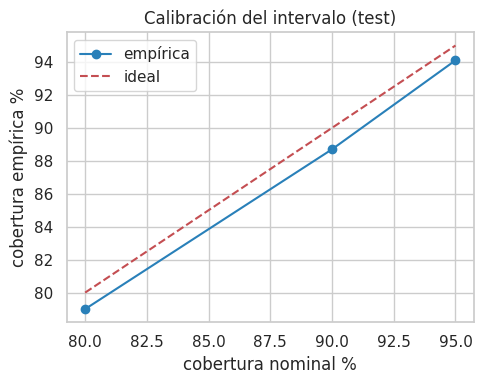

In [3]:
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.permutation(len(test)); half = len(idx)//2
cal, ev = idx[:half], idx[half:]
rel_cal = np.abs(y_test[cal] - y_pred[cal]) / np.maximum(y_test[cal], 1.0)

rows = []
for nominal in [0.80, 0.90, 0.95]:
    b = np.quantile(rel_cal, nominal)
    lo, hi = y_pred[ev]*(1-b), y_pred[ev]*(1+b)
    cov = np.mean((y_test[ev] >= lo) & (y_test[ev] <= hi)) * 100
    rows.append({"nominal_%": nominal*100, "banda_%": round(b*100, 1),
                 "cobertura_emp_%": round(cov, 1)})
calib = pd.DataFrame(rows)
print(calib.to_string(index=False))

# Banda de producción (la guardada en NB2) y su cobertura sobre TODO test
lo, hi = y_pred*(1-BAND), y_pred*(1+BAND)
cov_prod = np.mean((y_test >= lo) & (y_test <= hi)) * 100
print(f"\nBanda de producción +/-{BAND*100:.1f}%  ->  cobertura en test {cov_prod:.1f}% (objetivo {CONF:.0%})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(calib["nominal_%"], calib["cobertura_emp_%"], "o-", color="#2980b9", label="empírica")
ax.plot([80, 95], [80, 95], "r--", label="ideal")
ax.set_xlabel("cobertura nominal %"); ax.set_ylabel("cobertura empírica %")
ax.set_title("Calibración del intervalo (test)"); ax.legend()
plt.tight_layout(); plt.savefig(OUT/"10_calibracion.png", dpi=110); plt.show()

## 2. Importancia de features (permutation)

*Permutation importance* sobre test: mide cuánto empeora el MAE al mezclar cada columna.
Es agnóstico al modelo y respeta el pipeline completo. Sirve para **validar que las
features geográficas** (precio KNN, mediana por ciudad, distancia al centro) pesan, como
pedía la corrección.

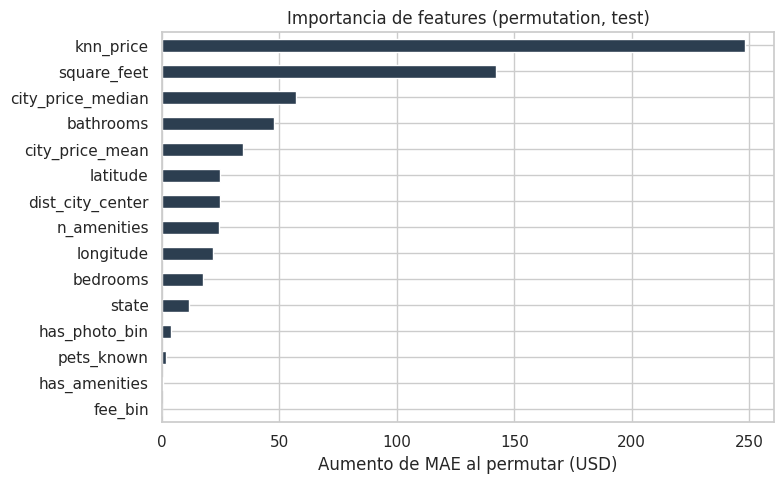

knn_price            248.1
square_feet          142.0
city_price_median     57.1
bathrooms             47.8
city_price_mean       34.6
latitude              24.8
dist_city_center      24.6
n_amenities           24.3
longitude             21.9
bedrooms              17.4
state                 11.3
has_photo_bin          3.9
pets_known             1.9
has_amenities          0.5
fee_bin                0.0
dtype: float64

In [4]:
samp = rng.choice(len(test), size=min(2000, len(test)), replace=False)
Xs, ys = X_test.iloc[samp], y_test[samp]
pi = permutation_importance(best_model, Xs, ys, n_repeats=5,
                            scoring="neg_mean_absolute_error",
                            random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=Xs.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot.barh(ax=ax, color="#2c3e50")
ax.set_xlabel("Aumento de MAE al permutar (USD)")
ax.set_title("Importancia de features (permutation, test)")
plt.tight_layout(); plt.savefig(OUT/"11_feature_importance.png", dpi=110); plt.show()
imp.sort_values(ascending=False).round(1)

## 3. Dónde falla el modelo (análisis de error global)

Sin cohortes: miramos el error de forma agregada. Distribución de residuos (¿sesgo?),
distribución del error relativo y los peores casos, para entender los límites del modelo.

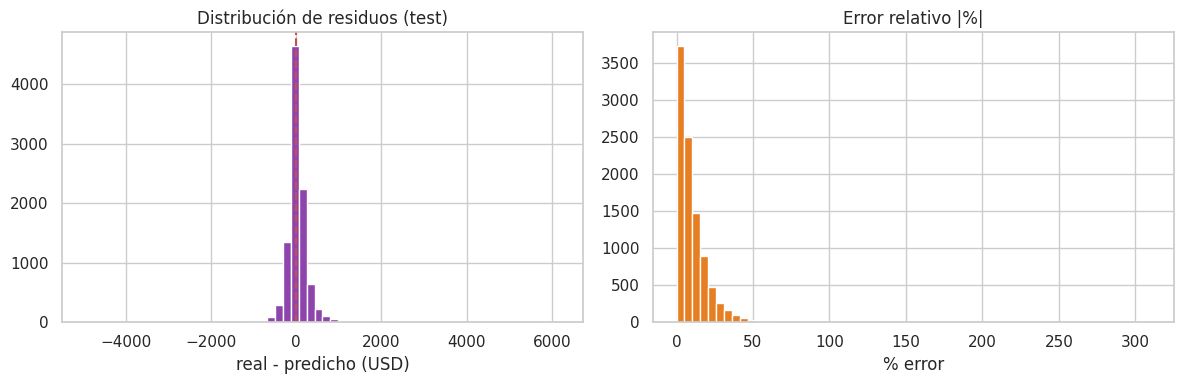

Residuo medio (sesgo): 28.7 USD | mediana |error|: 96 USD | mediana error rel: 7.3%

10 peores predicciones (por |error|):


,cityname,state,square_feet,bedrooms,bathrooms,price,pred,error
1594,Naples,FL,3021,4.0,3.0,9500.0,3322.0,6178.0
4403,Naples,FL,1336,2.0,2.0,1595.0,6536.0,-4941.0
4509,Naples,FL,2523,3.0,3.0,2400.0,6442.0,-4042.0
1845,Los Angeles,CA,3691,3.0,3.0,9500.0,5552.0,3948.0
281,Naples,FL,2003,2.0,2.0,6995.0,3080.0,3915.0
7212,Chicago,IL,2500,3.0,3.0,6995.0,3081.0,3914.0
6675,Naples,FL,1623,3.0,2.0,7000.0,3098.0,3902.0
9357,Naples,FL,2686,4.0,3.0,2500.0,6249.0,-3749.0
8467,Long Beach,CA,1440,2.0,2.0,6500.0,2908.0,3592.0
7833,Naples,FL,3359,4.0,3.5,9000.0,5690.0,3310.0


In [5]:
resid = y_test - y_pred
abs_err = np.abs(resid)
rel_err_pct = abs_err / np.maximum(y_test, 1.0) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(resid, bins=60, color="#8e44ad"); ax[0].axvline(0, color="r", ls="--")
ax[0].set_title("Distribución de residuos (test)"); ax[0].set_xlabel("real - predicho (USD)")
ax[1].hist(rel_err_pct, bins=60, color="#e67e22")
ax[1].set_title("Error relativo |%|"); ax[1].set_xlabel("% error")
plt.tight_layout(); plt.savefig(OUT/"12_errores.png", dpi=110); plt.show()

print(f"Residuo medio (sesgo): {resid.mean():.1f} USD | mediana |error|: {np.median(abs_err):.0f} USD | "
      f"mediana error rel: {np.median(rel_err_pct):.1f}%")

worst = test.copy()
worst["pred"]  = y_pred.round(0)
worst["error"] = resid.round(0)
worst["abs_err"] = abs_err.round(0)
cols = ["cityname", "state", "square_feet", "bedrooms", "bathrooms", "price", "pred", "error"]
print("\n10 peores predicciones (por |error|):")
worst.sort_values("abs_err", ascending=False)[cols].head(10)

## 4. Sesgo-varianza: over/underfitting y learning curves

Diagnóstico de **sesgo-varianza** para justificar por qué el modelo elegido está bien
regularizado (ni *underfit* ni *overfit*) antes de ponerlo a producir. Como NB3 solo guarda
el pipeline ganador, acá **re-entrenamos** versiones livianas (subsample + `cv=3`) — no busca
reproducir el MAE de NB2 al decimal, sino mostrar la *forma* de las curvas.

- **Validation curve** (XGBoost sobre `max_depth`): barre la complejidad del modelo. A la
  izquierda (árboles chatos) domina el **sesgo** → *underfitting* (train y validación altos y
  juntos). A la derecha (árboles profundos) domina la **varianza** → *overfitting* (train baja
  pero validación sube). El mínimo de validación es el punto de equilibrio.
- **Learning curves** de tres modelos con distinta capacidad (Ridge = alto sesgo,
  RandomForest = alta varianza, XGBoost = el ganador): MAE de train (línea punteada) vs MAE de
  validación (línea sólida) según el tamaño de train. La **brecha** entre ambas mide el
  *overfitting*; una **meseta alta** de ambas indica *underfitting*.

Diagnósticos sobre 8000 filas de train (subsample), cv=3


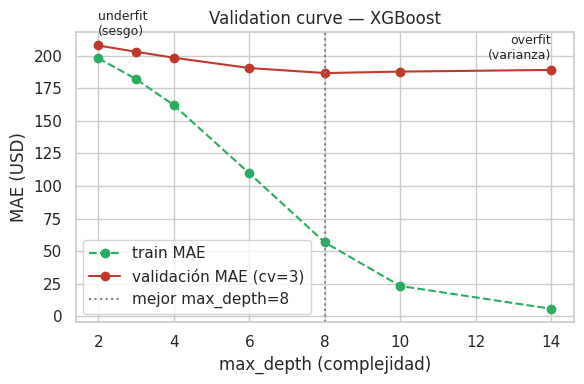

Brecha train/val en max_depth=8: 129.9 USD


In [6]:
# Pipeline auto-contenido (mismo preprocesamiento que NB2) para re-entrenar diagnósticos
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import learning_curve, validation_curve

def build_model(estimator):
    pre = ColumnTransformer([
        ("num", StandardScaler(), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         make_column_selector(dtype_include=object)),
    ])
    pipe = Pipeline([("pre", pre), ("est", estimator)])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

# Subsample de train para que los diagnósticos con CV corran rápido
X_train_full = make_X(train)
y_train_full = train["price"].to_numpy()
sub = rng.choice(len(train), size=min(8000, len(train)), replace=False)
X_tr, y_tr = X_train_full.iloc[sub], y_train_full[sub]
print(f"Diagnósticos sobre {len(X_tr)} filas de train (subsample), cv=3")

# --- Validation curve: XGBoost sobre max_depth (sesgo <-> varianza) ---
depths = [2, 3, 4, 6, 8, 10, 14]
xgb_base = XGBRegressor(n_estimators=300, learning_rate=0.07, subsample=0.8,
                        colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1)
tr_sc, va_sc = validation_curve(
    build_model(xgb_base), X_tr, y_tr,
    param_name="regressor__est__max_depth", param_range=depths,
    scoring="neg_mean_absolute_error", cv=3, n_jobs=-1)
tr_mae, va_mae = -tr_sc.mean(1), -va_sc.mean(1)
best_d = depths[int(np.argmin(va_mae))]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(depths, tr_mae, "o--", color="#27ae60", label="train MAE")
ax.plot(depths, va_mae, "o-",  color="#c0392b", label="validación MAE (cv=3)")
ax.axvline(best_d, color="gray", ls=":", label=f"mejor max_depth={best_d}")
ax.annotate("underfit\n(sesgo)", xy=(depths[0], va_mae[0]), xytext=(depths[0], va_mae[0]+8),
            fontsize=9, ha="left")
ax.annotate("overfit\n(varianza)", xy=(depths[-1], va_mae[-1]), xytext=(depths[-1], va_mae[-1]+8),
            fontsize=9, ha="right")
ax.set_xlabel("max_depth (complejidad)"); ax.set_ylabel("MAE (USD)")
ax.set_title("Validation curve — XGBoost"); ax.legend()
plt.tight_layout(); plt.savefig(OUT/"13_validation_curve.png", dpi=110); plt.show()
print(f"Brecha train/val en max_depth={best_d}: {va_mae[int(np.argmin(va_mae))]-tr_mae[int(np.argmin(va_mae))]:.1f} USD")

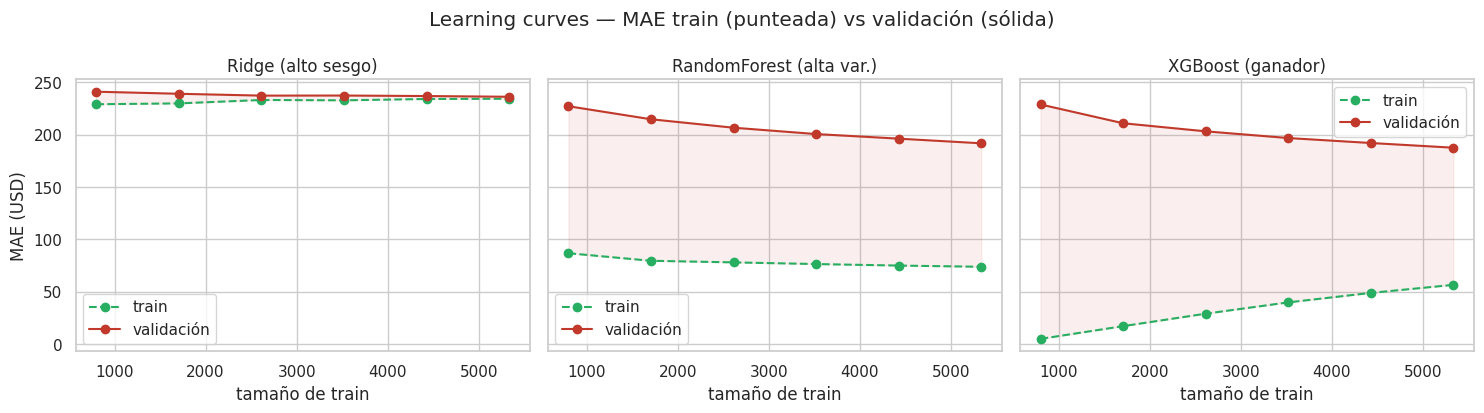

                  modelo  MAE train  MAE val  brecha
      Ridge (alto sesgo)      234.2    236.1     1.9
RandomForest (alta var.)       74.0    191.7   117.8
       XGBoost (ganador)       56.7    187.5   130.8


In [7]:
# --- Learning curves: 3 modelos con capacidad distinta ---
modelos = {
    "Ridge (alto sesgo)":       Ridge(alpha=1.0),
    "RandomForest (alta var.)": RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                                       random_state=RANDOM_STATE),
    "XGBoost (ganador)":        XGBRegressor(n_estimators=300, max_depth=best_d,
                                             learning_rate=0.07, subsample=0.8,
                                             colsample_bytree=0.8,
                                             random_state=RANDOM_STATE, n_jobs=-1),
}
sizes = np.linspace(0.15, 1.0, 6)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
resumen = []
for ax, (nombre, est) in zip(axes, modelos.items()):
    ts, tr_s, va_s = learning_curve(
        build_model(est), X_tr, y_tr, train_sizes=sizes, cv=3,
        scoring="neg_mean_absolute_error", n_jobs=-1, random_state=RANDOM_STATE)
    tr_m, va_m = -tr_s.mean(1), -va_s.mean(1)
    ax.plot(ts, tr_m, "o--", color="#27ae60", label="train")
    ax.plot(ts, va_m, "o-",  color="#c0392b", label="validación")
    ax.fill_between(ts, tr_m, va_m, color="#c0392b", alpha=0.08)
    ax.set_title(nombre); ax.set_xlabel("tamaño de train"); ax.legend()
    resumen.append({"modelo": nombre, "MAE train": round(tr_m[-1], 1),
                    "MAE val": round(va_m[-1], 1), "brecha": round(va_m[-1]-tr_m[-1], 1)})
axes[0].set_ylabel("MAE (USD)")
fig.suptitle("Learning curves — MAE train (punteada) vs validación (sólida)")
plt.tight_layout(); plt.savefig(OUT/"14_learning_curves.png", dpi=110); plt.show()

print(pd.DataFrame(resumen).to_string(index=False))

**Lectura.**
- **Validation curve:** con `max_depth` chico el MAE de validación es alto y pegado al de
  train → *underfitting* (sesgo). Al crecer la profundidad, el MAE de train sigue bajando pero
  el de validación toca fondo y vuelve a subir: ahí empieza el *overfitting* (varianza). El
  mínimo de validación marca la complejidad elegida.
- **Learning curves:** *Ridge* satura en un MAE alto con train y validación casi pegadas
  (brecha ~2 USD) → alto **sesgo** (underfit): más datos no lo salvan, le falta capacidad.
  Los modelos de árboles bajan mucho el MAE de train y abren una **brecha** con validación →
  **varianza**. Entre ellos *XGBoost* logra el **menor MAE de validación** (mejor
  generalización) que *RandomForest* — su brecha es parecida pero su error real es más bajo, y
  por eso es el ganador. *Nota:* las curvas corren sobre un subsample de 8k con `cv=3`, así que
  las brechas están **infladas** respecto del modelo final de NB2 (test MAE ~163) — interesa la
  *forma* relativa entre modelos, no el valor absoluto.

## 5. Función predictora

Interfaz de uso: recibe los datos de un aviso nuevo y devuelve **estimación + rango**.
Las features geográficas (distancia al centro, precio KNN, estadísticos por ciudad) se
reconstruyen con **los agregados de train** (mismo criterio anti-leakage de NB1), por lo
que la función es autónoma. Ciudades fuera del universo de train caen a la mediana global.

In [8]:
KNN_K = 10          # igual que NB1
EARTH_KM = 6371.0

# Lookups reconstruidos SOLO con train (sin leakage)
_centroids = train.groupby("city_key")[["latitude", "longitude"]].mean()
_g = train.groupby("city_key")["price"]
_city_med, _city_mean = _g.median(), _g.mean()
_glob_med = float(train["price"].median())
_tree = BallTree(np.radians(train[["latitude", "longitude"]].to_numpy()), metric="haversine")
_price_tr = train["price"].to_numpy()

def _haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return EARTH_KM * 2 * np.arcsin(np.sqrt(a))

def construir_features(*, square_feet, bedrooms, bathrooms, latitude, longitude,
                       state, cityname, amenities="", has_photo=False, fee=False,
                       pets_allowed=None):
    city_key = f"{state} | {cityname}"
    if city_key in _centroids.index:
        c = _centroids.loc[city_key]
        dist = float(_haversine_km(latitude, longitude, c["latitude"], c["longitude"]))
    else:
        dist = 0.0
    _, nn = _tree.query(np.radians([[latitude, longitude]]), k=KNN_K)
    knn_price = float(np.median(_price_tr[nn[0]]))
    n_am = 0 if not amenities else len(str(amenities).split(","))
    row = {
        "square_feet": square_feet, "bedrooms": bedrooms, "bathrooms": bathrooms,
        "latitude": latitude, "longitude": longitude, "dist_city_center": dist,
        "knn_price": knn_price,
        "city_price_median": float(_city_med.get(city_key, _glob_med)),
        "city_price_mean":   float(_city_mean.get(city_key, _glob_med)),
        "n_amenities": n_am, "has_amenities": int(n_am > 0),
        "has_photo_bin": int(bool(has_photo)), "fee_bin": int(bool(fee)),
        "pets_known": int(pets_allowed is not None), "state": state,
    }
    cols = NUM_FEATURES + ["state"]
    if PETS_MODE == "as_no":
        row["pets_cat"] = pets_allowed if pets_allowed is not None else "no"
        cols = cols + ["pets_cat"]
    return pd.DataFrame([row])[cols]

def predecir(**kw):
    X = construir_features(**kw)
    est = float(best_model.predict(X)[0])
    return {"estimacion_usd": round(est),
            "rango_min": round(est*(1-BAND)), "rango_max": round(est*(1+BAND)),
            "banda_%": round(BAND*100, 1), "confianza": CONF}

In [9]:
# Ejemplos de uso
ej1 = predecir(square_feet=850, bedrooms=1, bathrooms=1,
               latitude=34.05, longitude=-118.24, state="CA", cityname="Los Angeles",
               amenities="Pool,Gym,Parking", has_photo=True)
ej2 = predecir(square_feet=1600, bedrooms=3, bathrooms=2,
               latitude=35.82, longitude=-78.64, state="NC", cityname="Raleigh")
print("1BR chico en Los Angeles, CA :", ej1)
print("3BR en Raleigh, NC           :", ej2)

1BR chico en Los Angeles, CA : {'estimacion_usd': 3072, 'rango_min': 2387, 'rango_max': 3757, 'banda_%': 22.3, 'confianza': 0.9}
3BR en Raleigh, NC           : {'estimacion_usd': 1613, 'rango_min': 1253, 'rango_max': 1972, 'banda_%': 22.3, 'confianza': 0.9}


## 6. Deploy y monitoreo

**Uso previsto.** Herramienta de apoyo para que un propietario independiente fije un
*precio de referencia* al publicar. Entrega un número + un rango (no una tasación legal).

**Validación de entrada (guardarraíles).**
- Rechazar / advertir si la ciudad no está en el universo de train (sin comparables → el
  modelo cae a la mediana global y el rango deja de ser confiable).
- Rechazar valores fuera de los rangos de limpieza de NB1 (p. ej. `square_feet` < 120 o
  > 6000, `price` esperado fuera de [200, 10000]).

**Monitoreo de *drift*.**
- Los datos son de **2019**: el *nivel* de precios está desactualizado. En producción hay
  que re-escalar o reentrenar contra precios actuales.
- Vigilar drift de entrada (distribución de `square_feet`, mezcla de ciudades) y de salida
  (distribución de estimaciones) comparando contra la ventana de entrenamiento.
- Métricas online: MAE / error relativo contra precios finalmente publicados o cerrados;
  **cobertura real del intervalo** (¿el precio real cae dentro del rango el ~90% de las veces?).

**Reentrenamiento.**
- Gatillos: caída de cobertura por debajo del objetivo, aumento sostenido de MAE, o drift
  de entrada significativo.
- Recalcular **siempre** los agregados geográficos (KNN, medianas por ciudad) y la banda
  sólo con el nuevo train, para no reintroducir leakage.

**Limitaciones (heredadas del scope).** Sólo apartamentos, sólo ciudades con comparables,
sin estado de conservación ni regulaciones locales, sin estacionalidad.

## 7. Conclusiones

- El intervalo está **bien calibrado**: la cobertura empírica sigue a la nominal y la banda
  de producción cubre ~`CONF` en test.
- La **importancia de features** confirma el peso de las variables geográficas construidas
  sin leakage (precio KNN, mediana por ciudad, distancia al centro).
- El **análisis de error global** muestra dónde falla el modelo (colas / casos atípicos),
  sin necesidad de cohortes.
- El **diagnóstico sesgo-varianza** (validation + learning curves) confirma que XGBoost no
  está *underfit* como Ridge (que satura en MAE alto) y generaliza mejor que RandomForest
  (menor MAE de validación), justificando la elección de NB2.
- La **función predictora** deja el modelo listo para usar: datos de aviso → estimación +
  rango, con las features geográficas reconstruidas desde train.
- Se discutió **deploy y monitoreo** (validación de entrada, drift 2019, reentrenamiento).